![](img/NetworkX.jpg)

## Network Analysis with NetworkX

---

### Get prepared

#### Required installations

tbd

#### Imports

In [ ]:
import networkx as nx
import pandas as pd
pd.options.display.max_rows = 400
import matplotlib.pyplot as plt

---

### The *Game of Thrones* dataset

#### *GoT* Network

The network data that we're going to use in this lesson is taken from Andrew Beveridge and Jie Shan's paper, ["Network of Thrones."](https://www.maa.org/sites/default/files/pdf/Mathhorizons/NetworkofThrones%20%281%29.pdf)

These researchers calculated how many times each Game of Thrones character appeared within 15 words of another character in *A Storm of Swords*, the third book in the series.

| Network Element      | GOT |         
| :-------------: |:-------------:| 
| Node    | GOT character | 
| Edge     | Mutually mentioned within 15 words      | 
| Float | Decimal Numbers      |  
| Boolean | True/False     |   


For example, the following sentence counts as an "edge" or connection between Jon Snow and Sam Tarly:

> "It was the bastard **Jon Snow** who had taken that from him, him and his fat friend **Sam Tarly**."

> "Lucky it might be, and red it certainly was, but **Ygritte**’s hair was such a tangle that **Jon** was tempted to ask her if she only brushed it at the changing of the seasons."

> "**Arya** gave **Gendry** a sideways look. *He said it with me, like **Jon** used to do, back in Winterfell.* She missed **Jon Snow** the most of all her brothers.""

#### Get data

In [ ]:
got_df = pd.read_csv('./data/got-edges.csv')
#got_df

---

### Simple graph exploration

#### Create a Network From a Pandas DataFrame

In [ ]:
G = nx.from_pandas_edgelist(got_df, 'Source', 'Target', 'Weight')

#### Output a Network File

In [ ]:
nx.write_graphml(G, 'graphs/GOT-network.graphml')

#### Drawing the first GoT graph

plt.figure(figsize=(1,1)) would create an inch-by-inch image, which would be 80-by-80 pixels if you stick with the default dpi value.

In [ ]:
plt.figure(figsize=(12,12))
nx.draw(G, with_labels=True, node_color='skyblue', width=.3, font_size=8)
plt.show()

---

### Understanding a graph's basic properties

When you get graph data,
one of the first things you'll want to do is to
check its basic graph statistics:
the number of nodes
and the number of edges
that are represented in the graph.
This is a basic sanity-check on your data
that you don't want to skip out on.

#### Querying graph type

The first thing you need to know is the `type` of the graph:

In [ ]:
type(G)

#### Querying node information

Let's now query for the nodeset. See the first 5 nodes.
(We use the `list()` constructor to refer to the Python basic types.)

In [ ]:
list(G.nodes())[0:5]

Because a `G.nodes()` is iterable, 
we can query it for its length:

In [ ]:
len(G.nodes())

#### Querying edge information

In [ ]:
list(G.edges())[0:5]

---

### Add attributes to nodes

Who has the most number of connections in the network?

In [ ]:
deg = dict(nx.degree(G))
max_key = max(deg, key=deg.get)
max_key

Make the degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [ ]:
degrees = dict(nx.degree(G))
nx.set_node_attributes(G, name='degree', values=degrees)
dict(G.nodes(data='degree'))

Now, we can write things like:

In [ ]:
for n, attr in list(G.nodes(data=True))[0:5]:
    # n is the node
    # attr is the attributes dictionary
    print(f"{n} {attr}")

Additionally, we can see the attributes of individual nodes:

In [ ]:
G.nodes["Grenn"]

---

### Some calculations with graph measures

#### Calculate node degree

Make a Pandas dataframe from the degree data `G.nodes(data='degree')`, then sort from highest to lowest

In [ ]:
#print (G.nodes(data='degree'))
#for x in list(G.nodes(data='degree'))[0:5]:
#    print (type(x))
degree_df = pd.DataFrame(G.nodes(data='degree'), columns=['node', 'degree'])
degree_df = degree_df.sort_values(by='degree', ascending=False)
degree_df

Plot the nodes with the highest degree values

In [ ]:
num_nodes_to_inspect = 10
degree_df[:num_nodes_to_inspect].plot(x='node', y='degree', kind='barh').invert_yaxis()

#### Calculate Weighted Degree

Who has the most number of connections in the network (if you factor in edge weight)?

In [ ]:
nx.degree(G, weight='Weight')

Make the weighted degree values a `dict`ionary, then add it as a network "attribute" with `networkx.set_node_attributes()`

In [ ]:
weighted_degrees = dict(nx.degree(G, weight='Weight'))
nx.set_node_attributes(G, name='weighted_degree', values=weighted_degrees)

Make a Pandas dataframe from the degree data `G.nodes(data='weighted_degree')`, then sort from highest to lowest

In [ ]:
weighted_degree_df = pd.DataFrame(G.nodes(data='weighted_degree'), columns=['node', 'weighted_degree'])
weighted_degree_df = weighted_degree_df.sort_values(by='weighted_degree', ascending=False)
weighted_degree_df

Plot the nodes with the highest weighted degree values

In [ ]:
num_nodes_to_inspect = 10
weighted_degree_df[:num_nodes_to_inspect].plot(x='node', y='weighted_degree', color='orange', kind='barh').invert_yaxis()

#### Calculate Betweenness Centrality Scores

In graph theory, betweenness centrality is a measure of centrality in a graph based on shortest paths. 
In short: How many shortest paths pass a node?
More precise: What is the fraction of a graph's shortest paths that pass a certain node?

In [ ]:
nx.betweenness_centrality(G)

In [ ]:
betweenness_centrality = nx.betweenness_centrality(G)

Add `betweenness_centrality` (which is already a dictionary) as a node attribute with `networkx.set_node_attributes()`

In [ ]:
nx.set_node_attributes(G, name='betweenness', values=betweenness_centrality)

Make a Pandas dataframe from the betweenness data `G.nodes(data='betweenness')`, then sort from highest to lowest

In [ ]:
betweenness_df = pd.DataFrame(G.nodes(data='betweenness'), columns=['node', 'betweenness'])
betweenness_df = betweenness_df.sort_values(by='betweenness', ascending=False)
betweenness_df

Plot the nodes with the highest betweenness centrality scores

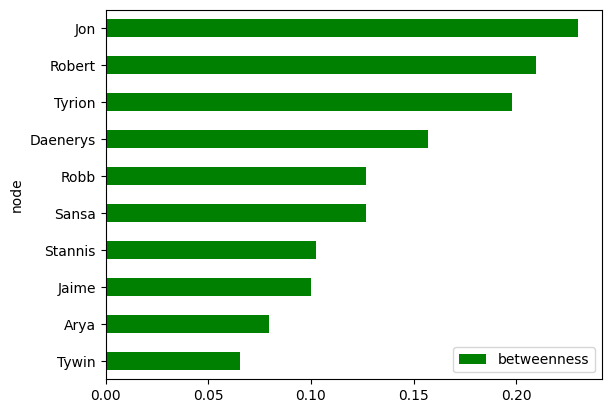

In [36]:
num_nodes_to_inspect = 10
betweenness_df[:num_nodes_to_inspect].plot(x='node', y='betweenness', color='green', kind='barh').invert_yaxis()